In [72]:
# total recursion
import urllib.request
import urllib.parse
import matplotlib.pyplot as plt
import numpy as np
import copy
import socket
import base64
import io

import time
import json
from pathlib import Path

In [73]:
with open("icon.json", "r", encoding="utf-8") as file:
    file_contents = file.read()
icon = json.loads(file_contents)

Text(0, 0.5, 'Y Coordinate')

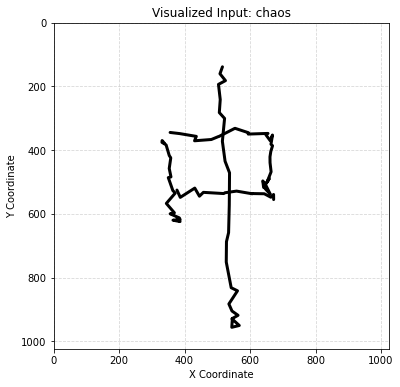

In [74]:
plt.figure(figsize=(6, 6))
for stroke in icon['brush_strokes']:
    xdata = [point['x'] for point in stroke]
    ydata = [point['y'] for point in stroke]
    xdata += 10*np.random.randn(len(xdata))
    ydata += 10*np.random.randn(len(xdata))
    plt.plot(xdata, ydata, color='black', linewidth=3, solid_capstyle='round')

plt.xlim(0, 1023)
plt.ylim(1023, 0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title(f"Visualized Input: {icon['message']}")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")    

=== LIVE SERVER ACTIVE ===

=== SERVER TERMINATED CLEANLY BY USER ===


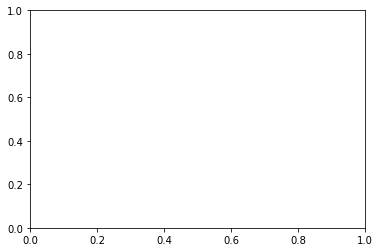

In [71]:

previous_state = copy.deepcopy(icon)
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as server:
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind(('127.0.0.1', 8000))
    server.listen(5)
    server.settimeout(0.5)
    print("=== LIVE SERVER ACTIVE ===")
    try:
        while True:
            try:
                conn, addr = server.accept()
            except socket.timeout:
                continue 
            with conn:
                raw_web_input = conn.makefile('r', encoding='utf-8').readline()
                if not raw_web_input:
                    continue
                try:
                    icon = json.loads(raw_web_input.strip())
                except (json.JSONDecodeError, ValueError):
                    pass
                previous_state = copy.deepcopy(icon)
                
                xdata = np.linspace(0,10,100)
                ydata = np.sin(xdata)
                ydata += 0.1*np.random.randn(len(xdata))
                dataset = {}
                dataset['xdata'] = xdata.tolist()
                dataset['ydata'] = ydata.tolist()
                dataset['xlabel'] = 'x'
                dataset['ylabel'] = 'y'
                dataset['ymin'] = -1.2
                dataset['ymax'] = 1.2
                dataset['icon'] = icon                
                plt.cla()
                
                plt.figure(figsize=(6, 6))
                for stroke in icon['brush_strokes']:
                    xdata = [point['x'] for point in stroke]
                    ydata = [point['y'] for point in stroke]
                    xdata += 4*np.random.randn(len(xdata))
                    ydata += 4*np.random.randn(len(xdata))
                    plt.plot(xdata, ydata, color='black', linewidth=3, solid_capstyle='round')

                plt.xlim(0, 1023)
                plt.ylim(1023, 0)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.title(f"Visualized Input: {icon['message']}")
                plt.xlabel("X Coordinate")
                plt.ylabel("Y Coordinate")                    
                plt.tight_layout()
                img_buf = io.BytesIO()
                plt.savefig(img_buf, format='png')
                plt.close()
                img_buf.seek(0)
                b64_string = base64.b64encode(img_buf.read()).decode('utf-8')
                imagedata = f"data:image/png;base64,{b64_string}"
                dataset['image'] = imagedata                
                payload = json.dumps(dataset) + "\n"
                conn.sendall(payload.encode('utf-8'))
                conn.shutdown(socket.SHUT_WR)

    except KeyboardInterrupt:
        print("\n=== SERVER TERMINATED CLEANLY BY USER ===")